# **Customer Segmentation Notebook**
This notebook focuses on **segmenting customers** based on their purchase behavior using **Recency, Frequency, and Monetary (RFM) analysis**.  
- The goal is to group customers into meaningful clusters (e.g., High-Value, Regular, Occasional, At-Risk) using **K-Means clustering**.  
- These segments help drive **targeted marketing, personalized offers, and retention strategies**, improving customer engagement and business growth.

# **K-MEANS CLUSTERING FOR CUSTOMER SEGMENTATION** 

# **What is K-Means?**  
K-Means is an **unsupervised machine learning algorithm** used to group similar data points into clusters **without any predefined labels**.  
It identifies **hidden patterns** in data by grouping customers with similar behavior together.  

**Why it matters in business:**  
- Simplifies large datasets into **meaningful customer segments**.  
- Enables **targeted marketing**, personalized promotions, and customer analysis.  
- Helps in **business decision-making** by identifying high-value, regular, occasional, and at-risk customers.  

---

# **Why K-Means for This Project?**  
We chose K-Means because:  
- Works well with **numerical features** like Recency, Frequency, and Monetary (RFM).  
- Scaled RFM data allows K-Means to measure **distances accurately**, producing clear and meaningful clusters.  

---

# **STEP 1: Selecting the Best K-Value**  
Before clustering, we need to determine the **optimal number of clusters (K)**.  
This is done using:  
1. **Elbow Curve** – Helps identify the point where adding more clusters does not significantly reduce the **within-cluster sum of squares (inertia)**.  
2. **Silhouette Score** – Measures how similar each customer is to its own cluster compared to other clusters; higher scores indicate better-defined clusters.  

# **STEP 2: Determining the Optimal Number of Clusters – Elbow Curve** 

The **Elbow Curve** is used to identify the **best number of clusters (K)** for customer segmentation.  

**How it works:**  
- We compute the **within-cluster sum of squares (inertia)** for different values of K.  
- As the number of clusters increases, inertia decreases because each cluster better fits the data.  
- At some point, the **rate of decrease sharply slows down**, forming an "elbow" in the curve.  

**Interpretation:**  
- The point where the curve starts to flatten (the elbow) indicates the **optimal number of clusters**.  
- Choosing this K ensures that the clusters are **well-separated** while avoiding unnecessary complexity.  

**Business Insight:**  
- Using the optimal K allows us to segment customers meaningfully, enabling **targeted marketing, personalized recommendations, and retention strategies**.

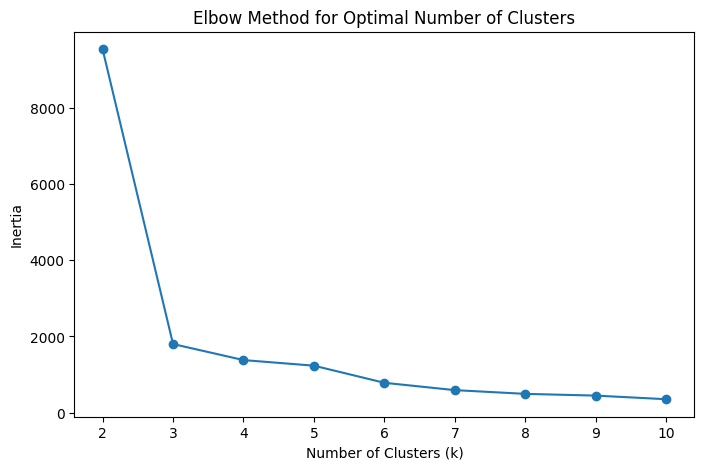

In [1]:
# First we import the required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 1:- Load the rfm_scaled.csv dataset
rfm_scaled = pd.read_csv("../data/rfm_scaled.csv")

# Inertia is used to measure how good the data points are grouped in the clusters
# It tells how far the points are from the center of the clusters
# Low Inertia score means, the clusters are tighter and better
# High Inertia score means, the clusters are spread out
inertia = []


# We select the range for the number of clusters
# We start from 2 because 1 Cluster puts the customers into one group, which will not support customer segmentation
# We end with 11, so we choose 10 clusters which is reasonably efficient for customer segmentation
k_range = range(2, 11)


for k in k_range: # We apply loop for each value of k_range (2-10)
    kmeans = KMeans(n_clusters=k, random_state=42) # We create a KMEANS model using the k-value 
    kmeans.fit(rfm_scaled) # We will train the KMEANS model on the rfm_scaled data
    inertia.append(kmeans.inertia_) # We will the store the inertia value for that particular k-value



# Plot the elbow curve
plt.figure(figsize=(8, 5)) # We iniatilise the figure dimensions
plt.plot(k_range, inertia, marker='o') # We plot using k_range, inertia 
plt.xlabel("Number of Clusters (k)") # We give the title for xlabel
plt.ylabel("Inertia") # We give the title for ylabel
plt.title("Elbow Method for Optimal Number of Clusters") # We give the title to the plot
plt.show()

# **Observation**
Why k = 4 is the best choice (simple explanation)

There is a very sharp drop in inertia from k = 2 to k = 3, meaning clustering improves a lot.

After k = 4, the curve starts to flatten, so adding more clusters does not give significant improvement.

This point (around k = 4) forms the “elbow” in the graph.

# **STEP 3: Evaluating Cluster Quality – Silhouette Score** 

The **Silhouette Score** measures how well each customer fits within their assigned cluster compared to other clusters.  

**How it works:**  
- For each customer, it calculates the difference between:  
  1. **Average distance to customers in the same cluster**  
  2. **Average distance to customers in the nearest neighboring cluster**  
- The score ranges from **-1 to +1**:  
  - **Close to +1:** Customer is well-matched to their cluster and far from others  
  - **Around 0:** Customer is on or near the boundary between clusters  
  - **Negative:** Customer may be in the wrong cluster  

**Why we use it:**  
- Helps select clusters that provide **clean, meaningful, and well-separated segmentation**.  
- Complements the Elbow Curve by **validating the quality** of the chosen number of clusters.  

**Business Insight:**  
- High Silhouette Scores indicate that customer segments are **cohesive and distinct**, allowing for **targeted marketing, personalized promotions, and better retention strategies**.

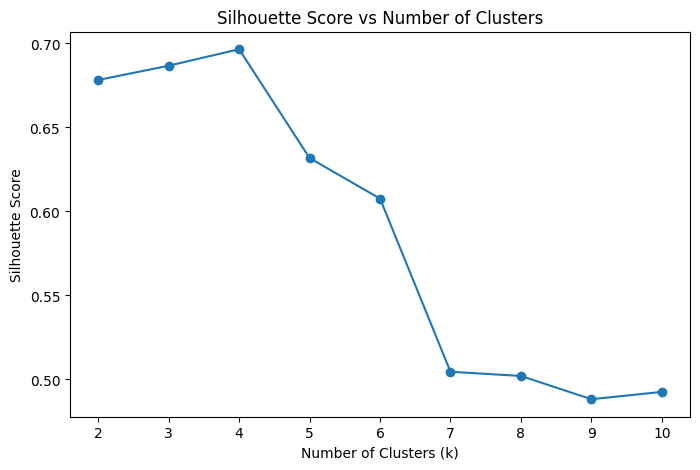

In [2]:
from sklearn.metrics import silhouette_score

# Store silhouette scores
silhouette_scores = []

# Range of k values to test
k_range = range(2, 11)

# Calculate silhouette score for each k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, cluster_labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

# **Observation**
The highest silhouette score occurs at k = 4 (around 0.70).

This means 4 clusters have the best separation and cohesion.

After k = 4, the silhouette score drops sharply, indicating poorer cluster quality.

Values from k ≥ 6 show much lower scores, meaning clusters start overlapping.

In [3]:
# We create KMEANS model with k-value as 4 becasue from elbow curve and silhouette score we obtained k=4 as best value
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit the model on scaled RFM data
kmeans.fit(rfm_scaled)

# Assign cluster labels
rfm_scaled['Cluster'] = kmeans.labels_ # This gives 4 clusters

# Calculate mean RFM values for each cluster
cluster_summary = rfm_scaled.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

rfm_scaled.head() # This shows the values of the first 5 customers

,Recency,Frequency,Monetary,Cluster
0,-0.915146,62.046504,62.402880,2
1,2.334829,-0.156931,2.661090,1
2,-0.905146,0.104611,0.066138,0
3,-0.175152,-0.026160,-0.023339,0
4,-0.735148,-0.156931,-0.024752,0


# **Observations:**

1. **Cluster 2 (High Frequency & Monetary, Low Recency):**  
   - Customers are very **active and high-spending**.  
   - Likely **high-value or loyal customers** who purchase frequently.  

2. **Cluster 1 (High Recency, Low Frequency & Monetary):**  
   - Customers **haven’t purchased in a long time** and spend less.  
   - These are potentially **at-risk customers** who may need re-engagement campaigns.  

3. **Cluster 0 (Low to Moderate RFM values):**  
   - Customers have **average or below-average engagement**.  
   - Could be **regular but low-spending customers** or occasional buyers.  


In [4]:
# Now we will add meaningful labels to the clusters in the below function
def label_cluster(row):
    if row['Recency'] < 30 and row['Frequency'] > 10 and row['Monetary'] > 500:
        return 'High-Value' # In this step if Recency<30, Frequency>10 and Monetary>500 we assign the label High Value to the cluster
    elif row['Frequency'] > 5:
        return 'Regular' # In this step if Recency<30, Frequency>5 and Monetary>500 we assign the label Regular to the cluster
    elif row['Recency'] > 180:
        return 'At-Risk' # In this step if Recency>180, Frequency>10 and Monetary>500 we assign the label At-Risk to the cluster
    else:
        return 'Occasional' # In this step if none of the above coinditions satisfy we assign the label Occasional to the cluster

rfm_scaled['Segment'] = rfm_scaled.apply(label_cluster, axis=1) # Now we will add a new column to store the cluster label

rfm_scaled.head() # This shows the values of the first 5 customers

,Recency,Frequency,Monetary,Cluster,Segment
0,-0.915146,62.046504,62.402880,2,Regular
1,2.334829,-0.156931,2.661090,1,Occasional
2,-0.905146,0.104611,0.066138,0,Occasional
3,-0.175152,-0.026160,-0.023339,0,Occasional
4,-0.735148,-0.156931,-0.024752,0,Occasional


# **Frequency VS Monetary**
This scatter plot shows how customers are grouped based on how often they purchase (Frequency) and how much money they spend (Monetary). Each point represents a customer, and different colors indicate different customer segments identified using RFM-based clustering.

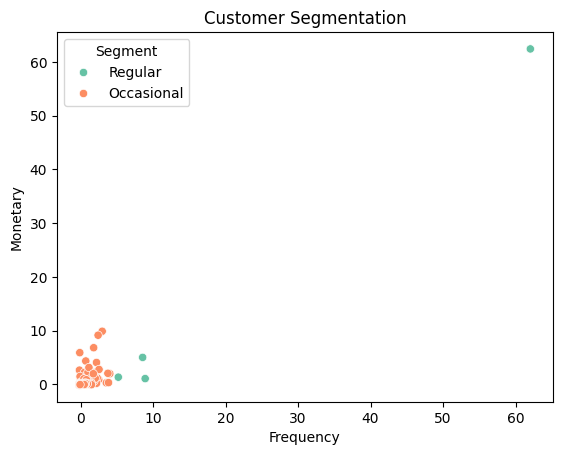

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=rfm_scaled, x='Frequency', y='Monetary', hue='Segment', palette='Set2')
plt.title('Customer Segmentation')
plt.show()

# **Observation**
Most customers are clustered at the lower Frequency and lower Monetary range, indicating Occasional customers who buy less often and spend less.

A small number of customers appear with higher Frequency and higher Monetary, representing Regular customers who purchase more frequently and contribute higher revenue.

# **Recency VS Frequency VS Monetary**
This 3D scatter plot visualizes customer segmentation using all three RFM dimensions together:

Recency (how recently a customer purchased),

Frequency (how often they purchase), and

Monetary (how much they spend).

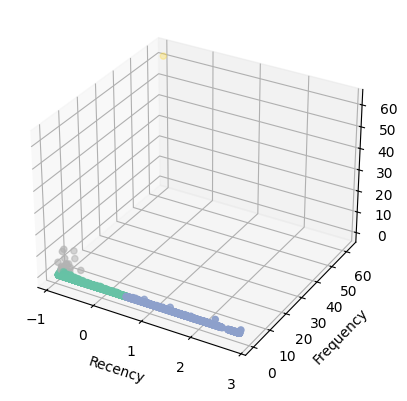

In [6]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rfm_scaled['Recency'], rfm_scaled['Frequency'], rfm_scaled['Monetary'], c=rfm_scaled['Cluster'], cmap='Set2')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.show()

# **Observation**
Most customers are concentrated near low Frequency and low Monetary values, showing that the majority are Occasional or low-engagement customers.

A very small number of points appear far away with high Frequency and high Monetary, indicating high-value or power customers who contribute significantly to revenue.

Customers with higher Recency values are positioned away from the main cluster, suggesting at-risk customers who have not purchased recently.

# **STEP 5: Saving the K-Means Model** 

After fitting the **K-Means clustering model** on the scaled RFM data, it is important to **save the trained model** for future use.  

**What this code does:**  
1. **Saves the trained K-Means model** (`kmeans_model.pkl`) using `joblib`.  
   - This allows us to **reuse the model** without retraining it every time.  
   - Useful for **real-time predictions** in the Streamlit app or other applications.  

2. **Ensures reproducibility:**  
   - The same clustering results can be obtained consistently across different sessions or environments.  

**Business Insight:**  
- By saving the model, we can **quickly classify new customers** into their respective segments.  
- This enables **targeted marketing, personalized recommendations, and retention strategies** without repeating preprocessing or training steps.

In [7]:
import joblib

joblib.dump(kmeans, '../models/kmeans_model.pkl') # In this step we will save the k-means model in the models folder

print("Sucessfully Saved the Model and Scaled Dataset")

Sucessfully Saved the Model and Scaled Dataset
